## Pre-conversion ephys quality check

Plots channel impedances and a snippet of raw traces directly from Open Ephys files

**Option A** — point `metadata_file_path` at your metadata YAML and leave the other variables as `None`.  
**Option B** — set `metadata_file_path = None` and fill in the individual paths/settings directly.

In [1]:
import yaml
from jdb_to_nwb.plotting.plot_ephys import (
    load_electrode_info,
    plot_channel_impedances,
    plot_raw_ephys_traces_from_metadata,
)

# Option A: just specify the path to your metadata file and all paths/info will be read from there
metadata_file_path = None  # e.g. "/path/to/metadata_IM-1875_20250720.yaml"

# Option B: specify relevant paths/info directly (to use these, set metadata_file_path = None)
probe_name            = "252-ch Silicon Probe, 4mm length, 80um pitch"
impedance_file_path   = "/Volumes/Tim/Ephys/IM-1951/20260519_impedance.csv"
openephys_folder_path = "/Volumes/Tim/Ephys/IM-1951/2026-05-19_16-04-08"
# Only need to change these if you want values different from the defaults
plug_order            = "chip_first"  # "chip_first" or "cable_first" ("chip_first" by default)
min_impedance_ohms    = 1e5     # 1e5 by default
max_impedance_ohms    = 3e6     # 3e6 by default

# ─────────────────────────────────────────────────────────────────────────────
if metadata_file_path is not None:
    with open(metadata_file_path) as f:
        metadata = yaml.safe_load(f)
else:
    metadata = {
        "ephys": {
            "probe": [probe_name],
            "impedance_file_path": impedance_file_path,
            "openephys_folder_path": openephys_folder_path,
            "plug_order": plug_order,
            "min_impedance_ohms": min_impedance_ohms,
            "max_impedance_ohms": max_impedance_ohms,
        }
    }

electrode_info = load_electrode_info(metadata)
n_total = len(electrode_info)
n_bad = int(electrode_info["bad_channel"].sum())
n_good = n_total - n_bad
print(f"Loaded {n_total} electrodes for '{metadata['ephys']['probe'][0]}'")
print(f"  Good channels: {n_good}")
print(f"  Bad channels:  {n_bad}")

/opt/anaconda3/envs/jdb_to_nwb/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/jdb_to_nwb/lib/python3.12/site-packages/spikeinterface/extractors/__init__.py:60: UserWarning: Importing classes at __init__ has been deprecated in favor of only importing function-size wrappers and will be removed in 0.105.0. For developers that prefer working with the class versions of extractors they can be imported from spikeinterface.extractors.extractor_classes
  warn(dep_msg)


Loaded 256 electrodes for '252-ch Silicon Probe, 4mm length, 80um pitch'
  Good channels: 223
  Bad channels:  33


### Impedance plot

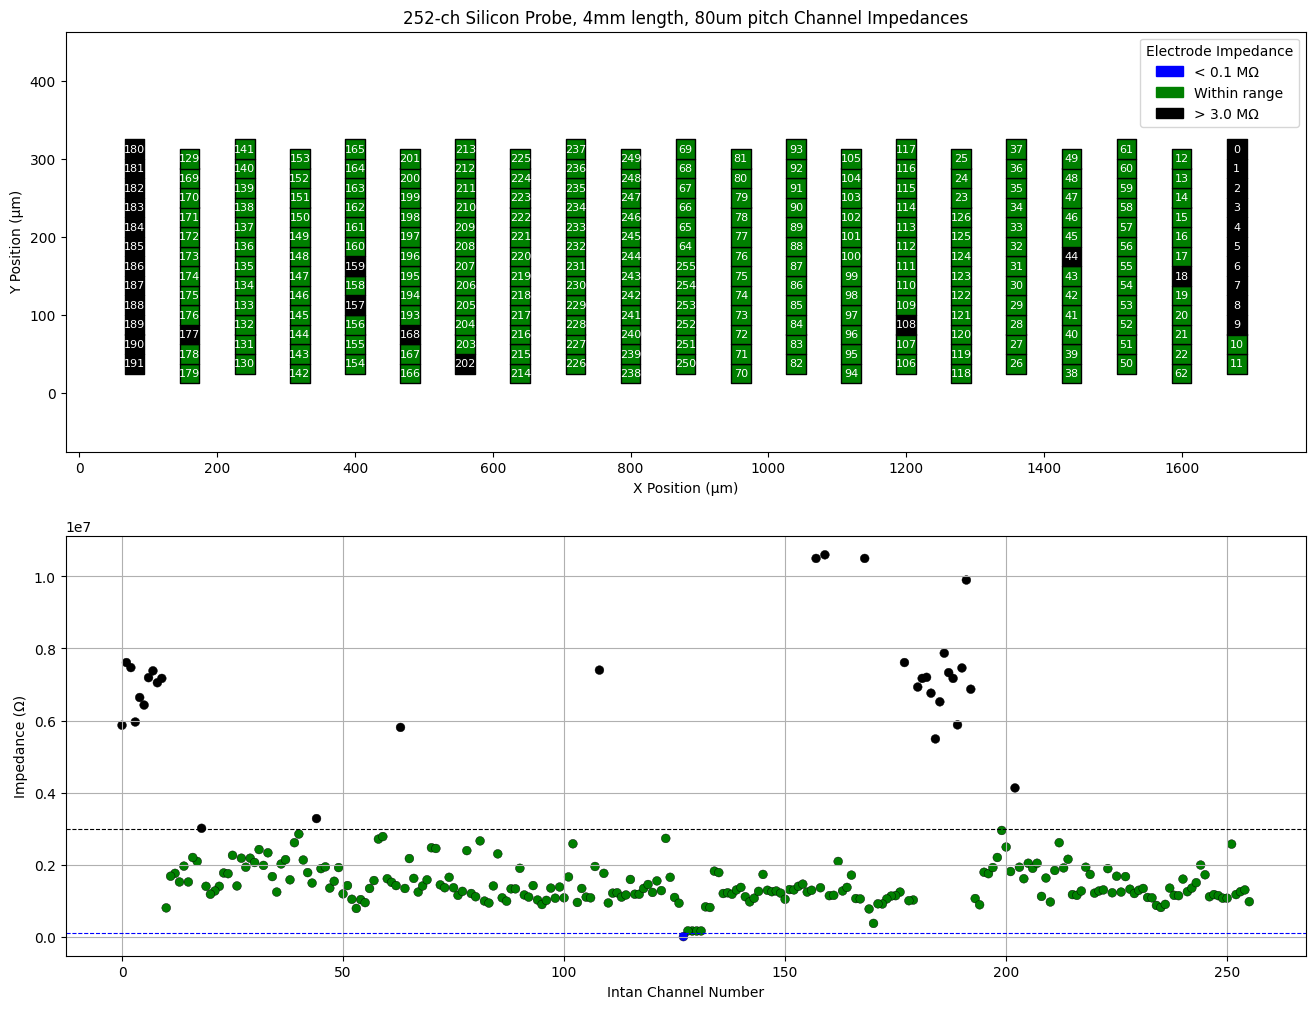

In [2]:
%matplotlib inline

fig = plot_channel_impedances(
    probe_name=metadata["ephys"]["probe"][0],
    electrode_info=electrode_info,
    min_impedance=metadata["ephys"].get("min_impedance_ohms", 1e5),
    max_impedance=metadata["ephys"].get("max_impedance_ohms", 3e6),
)

### Raw traces

Channels are ordered left-to-right by shank, top-to-bottom within each shank by depth. Black = odd shanks, red = even shanks.

In [ ]:
%matplotlib tk

start_time = 309.0  # seconds into the recording
duration = 1.5      # seconds to show

fig = plot_raw_ephys_traces_from_metadata(
    metadata=metadata,
    start_time=start_time,
    duration=duration,
)
fig.savefig("raw_ephys_traces.pdf") 
fig.show()